In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
data = pd.read_csv ("Desktop/Tesi/DatiMiele.csv")

#pd.set_option('display.max_rows', None) 

print (data)

        Na       K     Ca    Mg    Cu    Mn     Zn Regione
0    102.0   500.0   50.2  40.2  0.24  3.52  3.000   Lazio
1    101.0   508.0   60.6  41.0  0.22  2.95  3.310   Lazio
2     97.0   554.0   40.3  34.2  0.19  2.55  3.200   Lazio
3     95.0   478.0   42.3  36.5  0.30  2.65  3.540   Lazio
4    100.0   480.0   42.0  38.6  0.30  2.35  3.140   Lazio
..     ...     ...    ...   ...   ...   ...    ...     ...
188   18.9  2022.0  141.5  29.1  0.73  0.81  0.049  Marche
189   31.2   506.0  134.2  27.9  0.66  0.53  0.049  Marche
190   28.1   523.0  162.3  28.9  0.86  0.59  0.049  Marche
191   19.1   722.0  101.9  25.2  1.96  0.45  0.049  Marche
192   19.2   716.0   74.3  24.8  1.26  0.36  0.049  Marche

[193 rows x 8 columns]


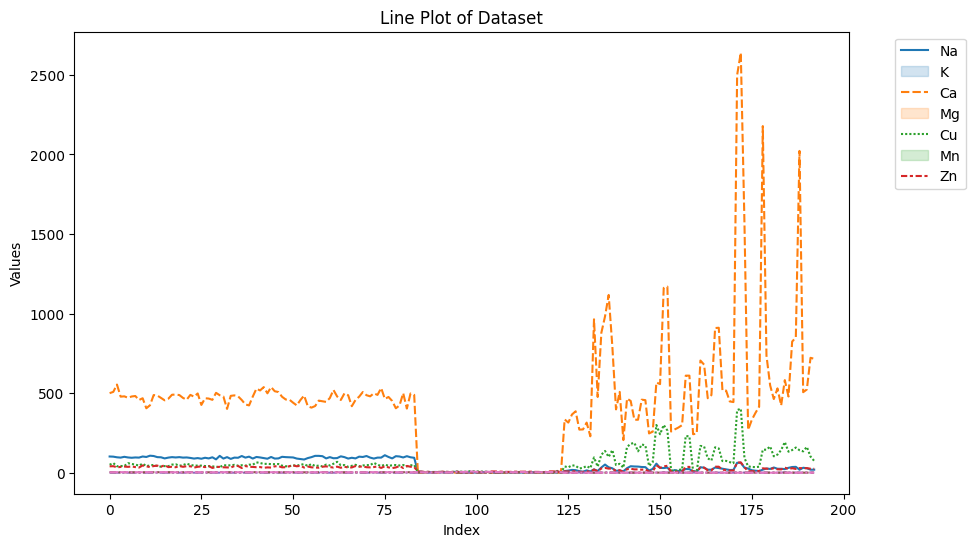

In [3]:
#Plotting a line graph
plt.figure(figsize=(10, 6))
sns.lineplot(data=data)
plt.title('Line Plot of Dataset')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend(data.columns[:-1], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [4]:
varianze = data.iloc[:, :-1].var()
print("Varianza (escludendo l'ultima colonna):")
print(varianze)

Varianza (escludendo l'ultima colonna):
Na      1698.132037
K     145694.168058
Ca      4577.738584
Mg       220.256066
Cu         0.286181
Mn         2.593923
Zn         3.212967
dtype: float64


In [5]:
x = data[['Na', 'K', 'Ca', 'Mg', 'Cu', 'Mn', 'Zn']] 
y = data['Regione'] 

#dataset = pd.DataFrame(data=data['data'], columns=data['Na', 'K', 'Ca', 'Mg', 'Cu', 'Mn', 'Zn'])

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

#Code Source of train_test_split function
https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation
https://github.com/scikit-learn/scikit-learn/blob/98ed9dc73/sklearn/model_selection/_split.py#L2734

    #Source code for cross validation 
    https://github.com/scikit-learn/scikit-learn/blob/98ed9dc73a86f5f11781a0e21f24c8f47979ec67/sklearn/model_selection/_validation.py

            #Source code  for actual random bit string generator by numpy
            https://github.com/bashtage/randomgen/blob/main/randomgen/pcg64.pyx

In [12]:
model = LogisticRegression(solver='lbfgs', max_iter=2000) #Default value: multi_class='multinomial
model.fit(x_train, y_train)

LogisticRegression(max_iter=2000)

In [8]:
y_pred = model.predict(x_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

report = classification_report(y_test, y_pred)
print('Classification Report:\n', report)

#Precision = veri positivi / (veri positivi + falsi positivi)
#Recall = veri positivi / (veri positivi + falsi negativi)
#F1 Score = 2 (precision*recall) / (precision + recall)    Media armonizzata di precision e recall (0-1)
#Support = Numero di volte che si presenta una classe nel dataset (classe = valori che può assumere variabile dipendente (regione))
#Accuracy = Numero di previsioni corrette / numero di previsioni totali (Poco significativo se le classi appaiono in modo disproporzionato nel dataset (lazio: 85, Spagna: 40, Marche: 69)
#Macro avg = Media per le metriche precision, recall, F1 score
#Weighted avg = Media ponderata in base al support delle metriche precision, recall, F1 score

for i in range(len(x_test)):
    print(f"Sample {i+1}: {x_test.iloc[i]} -> Predicted: {y_pred[i]}")

Accuracy: 1.0
Confusion Matrix:
 [[9 0 0]
 [0 5 0]
 [0 0 6]]
Classification Report:
               precision    recall  f1-score   support

       Lazio       1.00      1.00      1.00         9
      Marche       1.00      1.00      1.00         5
      Spagna       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Sample 1: Na     89.00
K     478.00
Ca     44.90
Mg     32.10
Cu      0.41
Mn      3.55
Zn      3.12
Name: 23, dtype: float64 -> Predicted: Lazio
Sample 2: Na     96.00
K     500.00
Ca     48.60
Mg     29.60
Cu      0.35
Mn      3.42
Zn      2.98
Name: 80, dtype: float64 -> Predicted: Lazio
Sample 3: Na    2.459
K     1.463
Ca    4.012
Mg    6.069
Cu    0.919
Mn    5.884
Zn    2.921
Name: 90, dtype: float64 -> Predicted: Spagna
Sample 4: Na    4.577
K     0.699
Ca    6.429
Mg    4.451
Cu    1.914
Mn    0.877
Zn    6.194
Name: 10

In [10]:
# New sample prediction

new_sample = np.array([[102.0, 500.0, 400, 40.2, 0.24, 3.52, 3.000]])

y_pred_new_sample = model.predict(new_sample)

print(f"La regione geografica per la seguente composizione chimica è: {y_pred_new_sample[0]}")

La regione geografica per la seguente composizione chimica è: Marche


C:\Users\adria\anaconda3\envs\Tesi_2\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
